In [ ]:
!pip install xgboost --quiet

In [ ]:
from google.colab import files
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.signal import resample

# for ML
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

#Data Extraction

In [ ]:
uploaded = files.upload()

Saving Arduino_reading.xlsx to Arduino_reading.xlsx


In [ ]:
# Replace filename automatically
file_name = list(uploaded.keys())[0]

# Read Excel file
df = pd.read_excel(file_name)

In [ ]:
# use full column - 11(L)
freq11 = pd.to_numeric(df.iloc[:, 11], errors='coerce').dropna()
trimmed11 = freq11.iloc[199:300] # needed frequency
print(freq11.head())

0    15972.0
1    16215.0
2    16102.0
3    15856.0
4    15835.0
Name: 16021, dtype: float64


In [ ]:
# use full column - 12(M)
freq12 = pd.to_numeric(df.iloc[:, 12], errors='coerce').dropna()
trimmed12 = freq12.iloc[60:107] # needed frequency
print(freq12.head())

0    23775.0
1    62505.0
2    17185.0
3    16885.0
4    17306.0
Name: 22346, dtype: float64


#Plot raw data

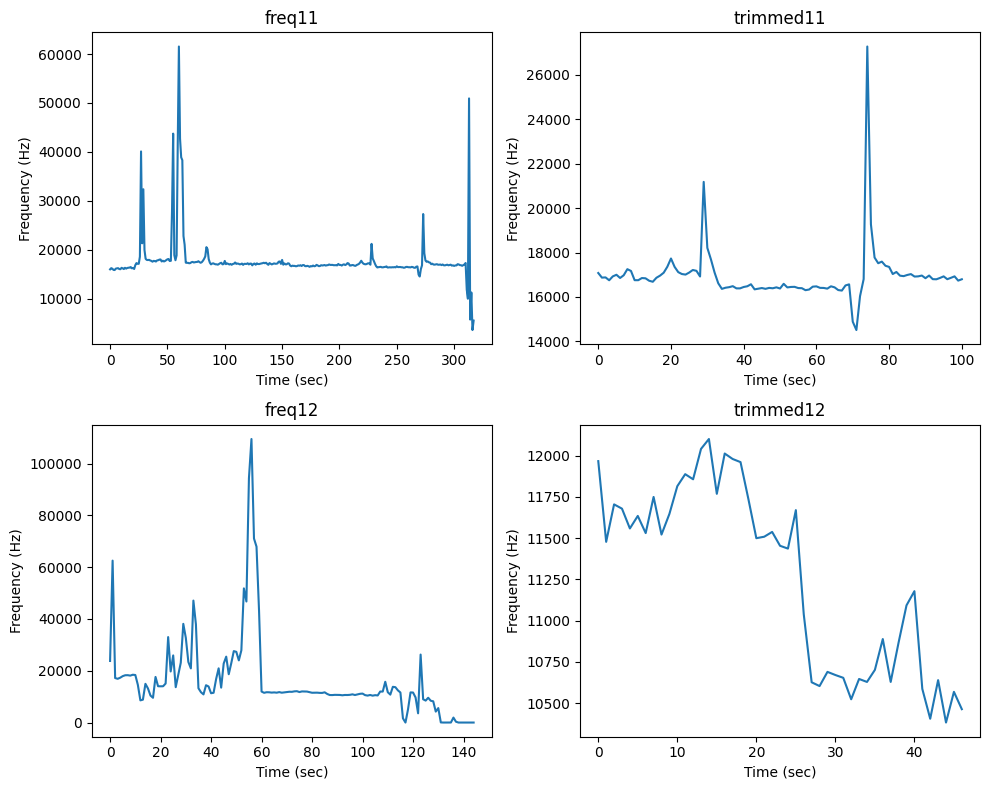

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(10, 8))

# Graph 1
axs[0, 0].plot(freq11.values)
axs[0, 0].set_xlabel("Time (sec)")
axs[0, 0].set_ylabel("Frequency (Hz)")
axs[0, 0].set_title("freq11")

# Graph 2
axs[0, 1].plot(trimmed11.values)
axs[0, 1].set_xlabel("Time (sec)")
axs[0, 1].set_ylabel("Frequency (Hz)")
axs[0, 1].set_title("trimmed11")

# Graph 3
axs[1, 0].plot(freq12.values)
axs[1, 0].set_xlabel("Time (sec)")
axs[1, 0].set_ylabel("Frequency (Hz)")
axs[1, 0].set_title("freq12")

# Graph 4
axs[1, 1].plot(trimmed12.values)
axs[1, 1].set_xlabel("Time (sec)")
axs[1, 1].set_ylabel("Frequency (Hz)")
axs[1, 1].set_title("trimmed12")

plt.tight_layout()
plt.show()

#Data Augementation

In [ ]:
def augment_frequency(data, t):
    aug = []

    for _ in range(t):
        x = data.copy()

        # Noise
        x = x + np.random.normal(0, 0.01 * np.std(x), size=len(x))

        # Scaling
        x = x * np.random.uniform(0.9, 1.1)

        # Shift
        x = np.roll(x, np.random.randint(-5, 5))

        # Time Stretch
        stretch = np.random.uniform(0.8, 1.2)
        x = resample(x, int(len(x) * stretch))

        aug.append(x)

    return aug

In [ ]:
aug11 = augment_frequency(trimmed11.values, 5)
aug12 = augment_frequency(trimmed12.values, 5)

flat11 = np.concatenate(aug11)
flat12 = np.concatenate(aug12)
flat11 = np.array(flat11)
flat12 = np.array(flat12)
print(flat11.shape)
print(flat12.shape)

(520,)
(207,)


#Plot Augmented data

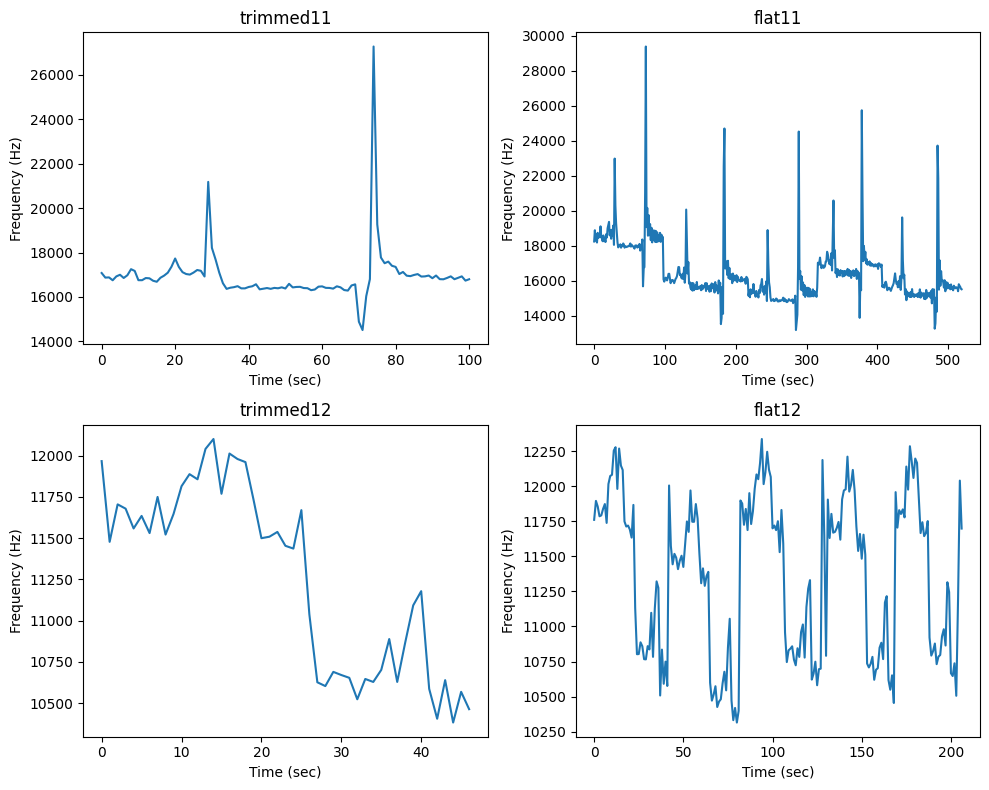

In [ ]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 2, figsize=(10, 8))

# 1 (pandas → needs .values)
axs[0, 0].plot(trimmed11.values)
axs[0, 0].set_title("trimmed11")
axs[0, 0].set_xlabel("Time (sec)")
axs[0, 0].set_ylabel("Frequency (Hz)")

# 2 (numpy → NO .values)
axs[0, 1].plot(flat11)
axs[0, 1].set_title("flat11")
axs[0, 1].set_xlabel("Time (sec)")
axs[0, 1].set_ylabel("Frequency (Hz)")

# 3 (pandas)
axs[1, 0].plot(trimmed12.values)
axs[1, 0].set_title("trimmed12")
axs[1, 0].set_xlabel("Time (sec)")
axs[1, 0].set_ylabel("Frequency (Hz)")

# 4 (numpy)
axs[1, 1].plot(flat12)
axs[1, 1].set_title("flat12")
axs[1, 1].set_xlabel("Time (sec)")
axs[1, 1].set_ylabel("Frequency (Hz)")

plt.tight_layout()
plt.show()

# Save Aug data in .xlsx

In [ ]:
df1 = pd.DataFrame(flat11, columns=["Frequency"])
df1.to_excel("flat11.xlsx", index=False) # save to excel

df2 = pd.DataFrame(flat12, columns=["Frequency"])
df2.to_excel("flat12.xlsx", index=False)


#Feature engineering

In [ ]:
time11 = np.arange(len(flat11))        # 0 to n (index as time)
data11 = np.column_stack((time11, flat11))

time12 = np.arange(len(flat12))
data12 = np.column_stack((time12, flat12))

print(data11[:5])
print("--data11 \n \n")
print(data12[:5])
print("--data12")



[[0.00000000e+00 1.82462310e+04]
 [1.00000000e+00 1.88897916e+04]
 [2.00000000e+00 1.82971582e+04]
 [3.00000000e+00 1.86501388e+04]
 [4.00000000e+00 1.81877073e+04]]
--data11 
 

[[0.00000000e+00 1.17598211e+04]
 [1.00000000e+00 1.18947773e+04]
 [2.00000000e+00 1.18545555e+04]
 [3.00000000e+00 1.17850615e+04]
 [4.00000000e+00 1.17913779e+04]]
--data12


In [ ]:
df_11 = pd.DataFrame(data11, columns=['time_sec', 'frequency'])
df_12 = pd.DataFrame(data12, columns=['time_sec', 'frequency'])

# apply same formula
freq_min, freq_max = df_11['frequency'].min(), df_11['frequency'].max()
df_11['label'] = (1 - (df_11['frequency'] - freq_min) / (freq_max - freq_min)) * 100

freq_min, freq_max = df_12['frequency'].min(), df_12['frequency'].max()
df_12['label'] = (1 - (df_12['frequency'] - freq_min) / (freq_max - freq_min)) * 100

df_12['time_sec'] = df_12['time_sec'] + 500
df_final = pd.concat([df_11, df_12], ignore_index=True)


# ML work

##  ML function for single data

In [ ]:
def ml(data):
    #  Load from array
    df = pd.DataFrame(data, columns=['time_sec', 'frequency'])
    print(f"Loaded {df.shape[0]} rows")
    print(df.head())

    #  Feature Engineering
    df['hour']              = (df['time_sec'] // 3600) % 24
    df['minute']            = (df['time_sec'] % 3600) // 60
    df['day']               = (df['time_sec'] // 86400).astype(int)
    df['is_night']          = ((df['hour'] >= 20) | (df['hour'] <= 6)).astype(int)
    df['time_sin']          = np.sin(2 * np.pi * df['hour'] / 24)
    df['time_cos']          = np.cos(2 * np.pi * df['hour'] / 24)
    df['freq_rolling_mean'] = df['frequency'].rolling(5, min_periods=1).mean()
    df['freq_rolling_std']  = df['frequency'].rolling(5, min_periods=1).std().fillna(0)
    df['freq_rolling_min']  = df['frequency'].rolling(5, min_periods=1).min()
    df['freq_rolling_max']  = df['frequency'].rolling(5, min_periods=1).max()
    df['freq_diff']         = df['frequency'].diff().fillna(0)
    df['freq_lag1']         = df['frequency'].shift(1).bfill()
    df['freq_lag2']         = df['frequency'].shift(2).bfill()
    df['freq_lag3']         = df['frequency'].shift(3).bfill()

    # Label
    freq_min, freq_max = df['frequency'].min(), df['frequency'].max()
    df['label'] = (1 - (df['frequency'] - freq_min) / (freq_max - freq_min)) * 100
    print(f"\nLabel range: {df['label'].min():.2f} → {df['label'].max():.2f}")
    print(df['label'].describe())

    # Features & Split
    feature_cols = [
        'frequency',
        'hour', 'minute', 'day', 'is_night', 'time_sin', 'time_cos',
        'freq_rolling_mean', 'freq_rolling_std', 'freq_rolling_min', 'freq_rolling_max',
        'freq_diff',
        'freq_lag1', 'freq_lag2', 'freq_lag3'
    ]

    X, y  = df[feature_cols], df['label']
    split = int(len(df) * 0.8)
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    scaler     = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc  = scaler.transform(X_test)

    print(f"\nTotal rows: {len(df)} | Train: {len(X_train)} | Test: {len(X_test)}")

    # Models
    models = {
        'Linear Regression': LinearRegression(),
        'Random Forest':     RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42),
        'XGBoost':           XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=42, verbosity=0),
    }

    print(f"\n{'Model':<22} {'RMSE':>8} {'MAE':>8} {'R²':>8} {'MAPE(%)':>10}")
    print("-" * 60)

    results = {}
    for name, model in models.items():
        model.fit(X_train_sc, y_train)
        preds = model.predict(X_test_sc)

        rmse  = np.sqrt(mean_squared_error(y_test, preds))
        mae   = mean_absolute_error(y_test, preds)
        r2    = r2_score(y_test, preds)
        mape  = np.mean(np.abs((y_test - preds) / y_test)) * 100

        results[name] = {'preds': preds, 'rmse': rmse, 'mae': mae, 'r2': r2, 'mape': mape}

        print(f"{name:<22} {rmse:>8.2f} {mae:>8.2f} {r2:>8.3f} {mape:>10.2f}")

    # Feature importance
    def get_importance(name, model):
        if hasattr(model, 'feature_importances_'):
            return np.abs(model.feature_importances_)
        return np.abs(model.coef_)

    colors = {
        'Linear Regression': 'royalblue',
        'Random Forest':     'steelblue',
        'XGBoost':           'darkcyan',
    }

    #  Plots
    fig, axes = plt.subplots(3, 2, figsize=(16, 14))
    fig.suptitle(f'Leaf Wetness — All Models  ({len(df)} samples)', fontsize=15, fontweight='bold')

    for i, (name, model) in enumerate(models.items()):
        preds = results[name]['preds']
        rmse  = results[name]['rmse']
        r2    = results[name]['r2']
        color = colors[name]

        importances = pd.Series(get_importance(name, model), index=feature_cols).sort_values()
        importances.plot(kind='barh', color=color, ax=axes[i, 0])
        axes[i, 0].set_title(f'{name}  Feature Importance', fontweight='bold')

        axes[i, 1].plot(df['time_sec'].iloc[split:].values, y_test.values, label='Actual', color='gray')
        axes[i, 1].plot(df['time_sec'].iloc[split:].values, preds, label='Predicted', color=color)
        axes[i, 1].set_title(f'{name} | RMSE={rmse:.2f} R²={r2:.3f}', fontweight='bold')
        axes[i, 1].legend()

    plt.tight_layout()
    plt.show()


## ML function for merged data

In [ ]:
def ml2(data):
    #Load from array
    df = pd.DataFrame(data, columns=['time_sec', 'frequency','label'])
    print(f"Loaded {df.shape[0]} rows")
    print(df.head())

    # Feature Engineering
    df['hour']              = (df['time_sec'] // 3600) % 24
    df['minute']            = (df['time_sec'] % 3600) // 60
    df['day']               = (df['time_sec'] // 86400).astype(int)
    df['is_night']          = ((df['hour'] >= 20) | (df['hour'] <= 6)).astype(int)
    df['time_sin']          = np.sin(2 * np.pi * df['hour'] / 24)
    df['time_cos']          = np.cos(2 * np.pi * df['hour'] / 24)
    df['freq_rolling_mean'] = df['frequency'].rolling(5, min_periods=1).mean()
    df['freq_rolling_std']  = df['frequency'].rolling(5, min_periods=1).std().fillna(0)
    df['freq_rolling_min']  = df['frequency'].rolling(5, min_periods=1).min()
    df['freq_rolling_max']  = df['frequency'].rolling(5, min_periods=1).max()
    df['freq_diff']         = df['frequency'].diff().fillna(0)
    df['freq_lag1']         = df['frequency'].shift(1).bfill()
    df['freq_lag2']         = df['frequency'].shift(2).bfill()
    df['freq_lag3']         = df['frequency'].shift(3).bfill()

    print(f"\nLabel range: {df['label'].min():.2f} → {df['label'].max():.2f}")
    print(df['label'].describe())

    #  Features & Time-based Split (full dataset, 80/20)
    feature_cols = [
        'frequency',
        'hour', 'minute', 'day', 'is_night', 'time_sin', 'time_cos',
        'freq_rolling_mean', 'freq_rolling_std', 'freq_rolling_min', 'freq_rolling_max',
        'freq_diff',
        'freq_lag1', 'freq_lag2', 'freq_lag3'
    ]

    X, y  = df[feature_cols], df['label']
    split = int(len(df) * 0.8)
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    scaler     = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc  = scaler.transform(X_test)

    print(f"\nTotal rows: {len(df)} | Train: {len(X_train)} | Test: {len(X_test)}")

    # Train & Evaluate
    models = {
        'Linear Regression': LinearRegression(),
        'Random Forest':     RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42),
        'XGBoost':           XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=42, verbosity=0),
    }

    print(f"\n{'Model':<22} {'RMSE':>8} {'MAE':>8} {'R²':>8} {'MAPE(%)':>10}")
    print("-" * 60)
    results = {}
    for name, model in models.items():
        model.fit(X_train_sc, y_train)
        preds = model.predict(X_test_sc)
        rmse  = np.sqrt(mean_squared_error(y_test, preds))
        mae   = mean_absolute_error(y_test, preds)
        r2    = r2_score(y_test, preds)
        mape  = np.mean(np.abs((y_test - preds) / y_test)) * 100

        results[name] = {'preds': preds, 'rmse': rmse, 'mae': mae, 'r2': r2, 'mape': mape}
        print(f"{name:<22} {rmse:>8.2f} {mae:>8.2f} {r2:>8.3f} {mape:>10.2f}")

    # Feature importance helper
    def get_importance(name, model):
        if hasattr(model, 'feature_importances_'):
            return np.abs(model.feature_importances_)
        return np.abs(model.coef_)

    colors = {
        'Linear Regression': 'royalblue',
        'Random Forest':     'steelblue',
        'XGBoost':           'darkcyan',
    }

    # Plots: 3 rows × 2 cols
    fig, axes = plt.subplots(3, 2, figsize=(16, 14))
    fig.suptitle(f'Leaf Wetness - All Models  ({len(df)} samples)', fontsize=15, fontweight='bold')

    for i, (name, model) in enumerate(models.items()):
        preds = results[name]['preds']
        rmse  = results[name]['rmse']
        r2    = results[name]['r2']
        color = colors[name]

        # Feature importance
        importances = pd.Series(get_importance(name, model), index=feature_cols).sort_values()
        importances.plot(kind='barh', color=color, ax=axes[i, 0])
        axes[i, 0].set_title(f'{name} Feature Importance', fontweight='bold')
        axes[i, 0].set_xlabel('Importance score')
        axes[i, 0].tick_params(labelsize=9)

        # Actual vs Predicted
        axes[i, 1].plot(df['time_sec'].iloc[split:].values, y_test.values,
                        label='Actual',    color='gray', alpha=0.7,  linewidth=1)
        axes[i, 1].plot(df['time_sec'].iloc[split:].values, preds,
                        label='Predicted', color=color,  alpha=0.85, linewidth=1)
        axes[i, 1].set_title(f'{name} Actual vs Predicted  |  RMSE={rmse:.2f}  R²={r2:.3f}', fontweight='bold')
        axes[i, 1].set_xlabel('Time (seconds)')
        axes[i, 1].set_ylabel('Wetness level')
        axes[i, 1].legend(fontsize=9)
        axes[i, 1].tick_params(labelsize=9)

    plt.tight_layout()
    plt.show()


# Testing

## Testing on single dataset

Loaded 520 rows
   time_sec     frequency
0       0.0  18246.230972
1       1.0  18889.791627
2       2.0  18297.158158
3       3.0  18650.138808
4       4.0  18187.707326

Label range: 0.00 → 100.00
count    520.000000
mean      79.670531
std       10.193854
min        0.000000
25%       76.180454
50%       82.387699
75%       85.952933
max      100.000000
Name: label, dtype: float64

Total rows: 520 | Train: 416 | Test: 104

Model                      RMSE      MAE       R²    MAPE(%)
------------------------------------------------------------
Linear Regression          0.00     0.00    1.000       0.00
Random Forest              0.55     0.17    0.994       0.26
XGBoost                    0.82     0.21    0.988       0.37


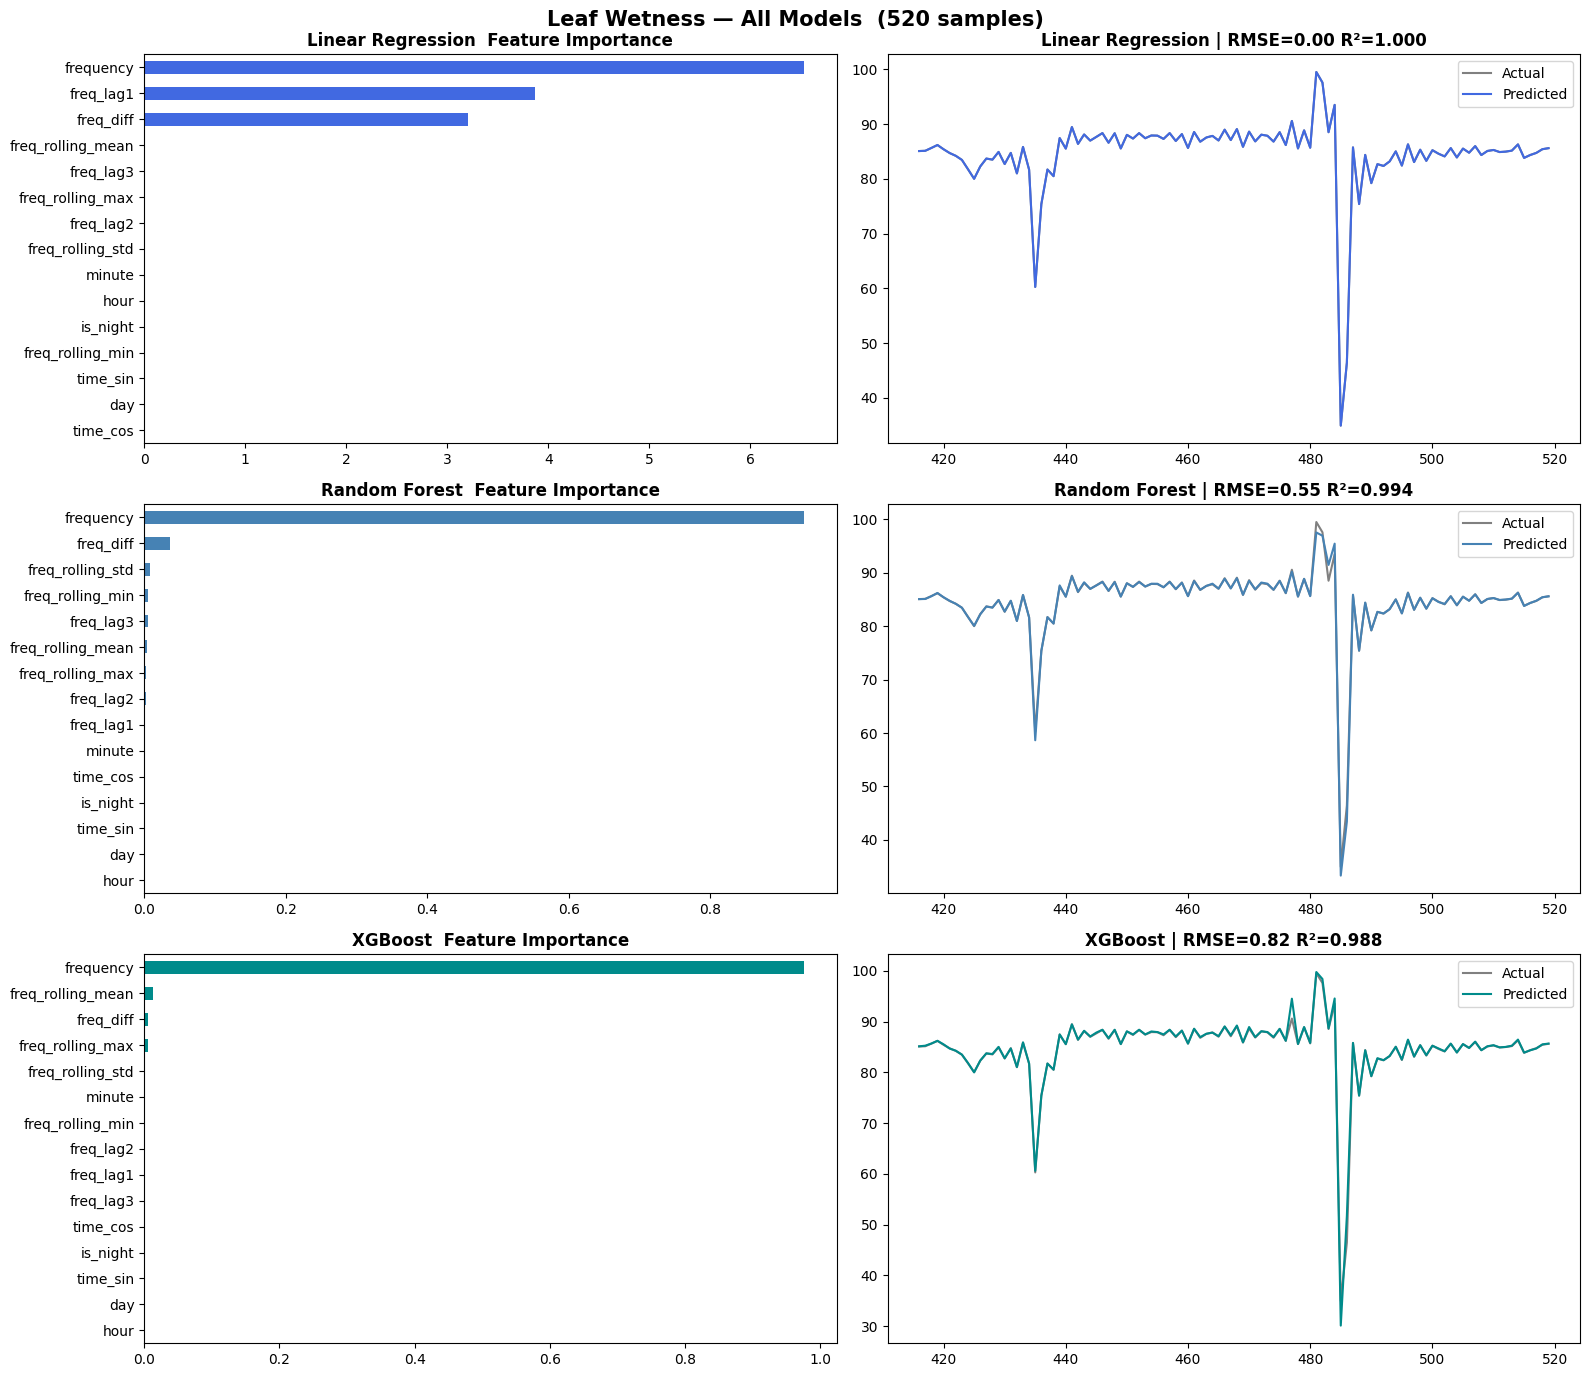

In [ ]:
ml(data11)

Loaded 207 rows
   time_sec     frequency
0       0.0  11759.821144
1       1.0  11894.777278
2       2.0  11854.555529
3       3.0  11785.061495
4       4.0  11791.377874

Label range: 0.00 → 100.00
count    207.000000
mean      48.070816
std       28.082535
min        0.000000
25%       24.921595
50%       40.837869
75%       76.424986
max      100.000000
Name: label, dtype: float64

Total rows: 207 | Train: 165 | Test: 42

Model                      RMSE      MAE       R²    MAPE(%)
------------------------------------------------------------
Linear Regression          0.00     0.00    1.000       0.00
Random Forest              0.55     0.39    1.000       2.51
XGBoost                    0.82     0.63    0.999       2.25


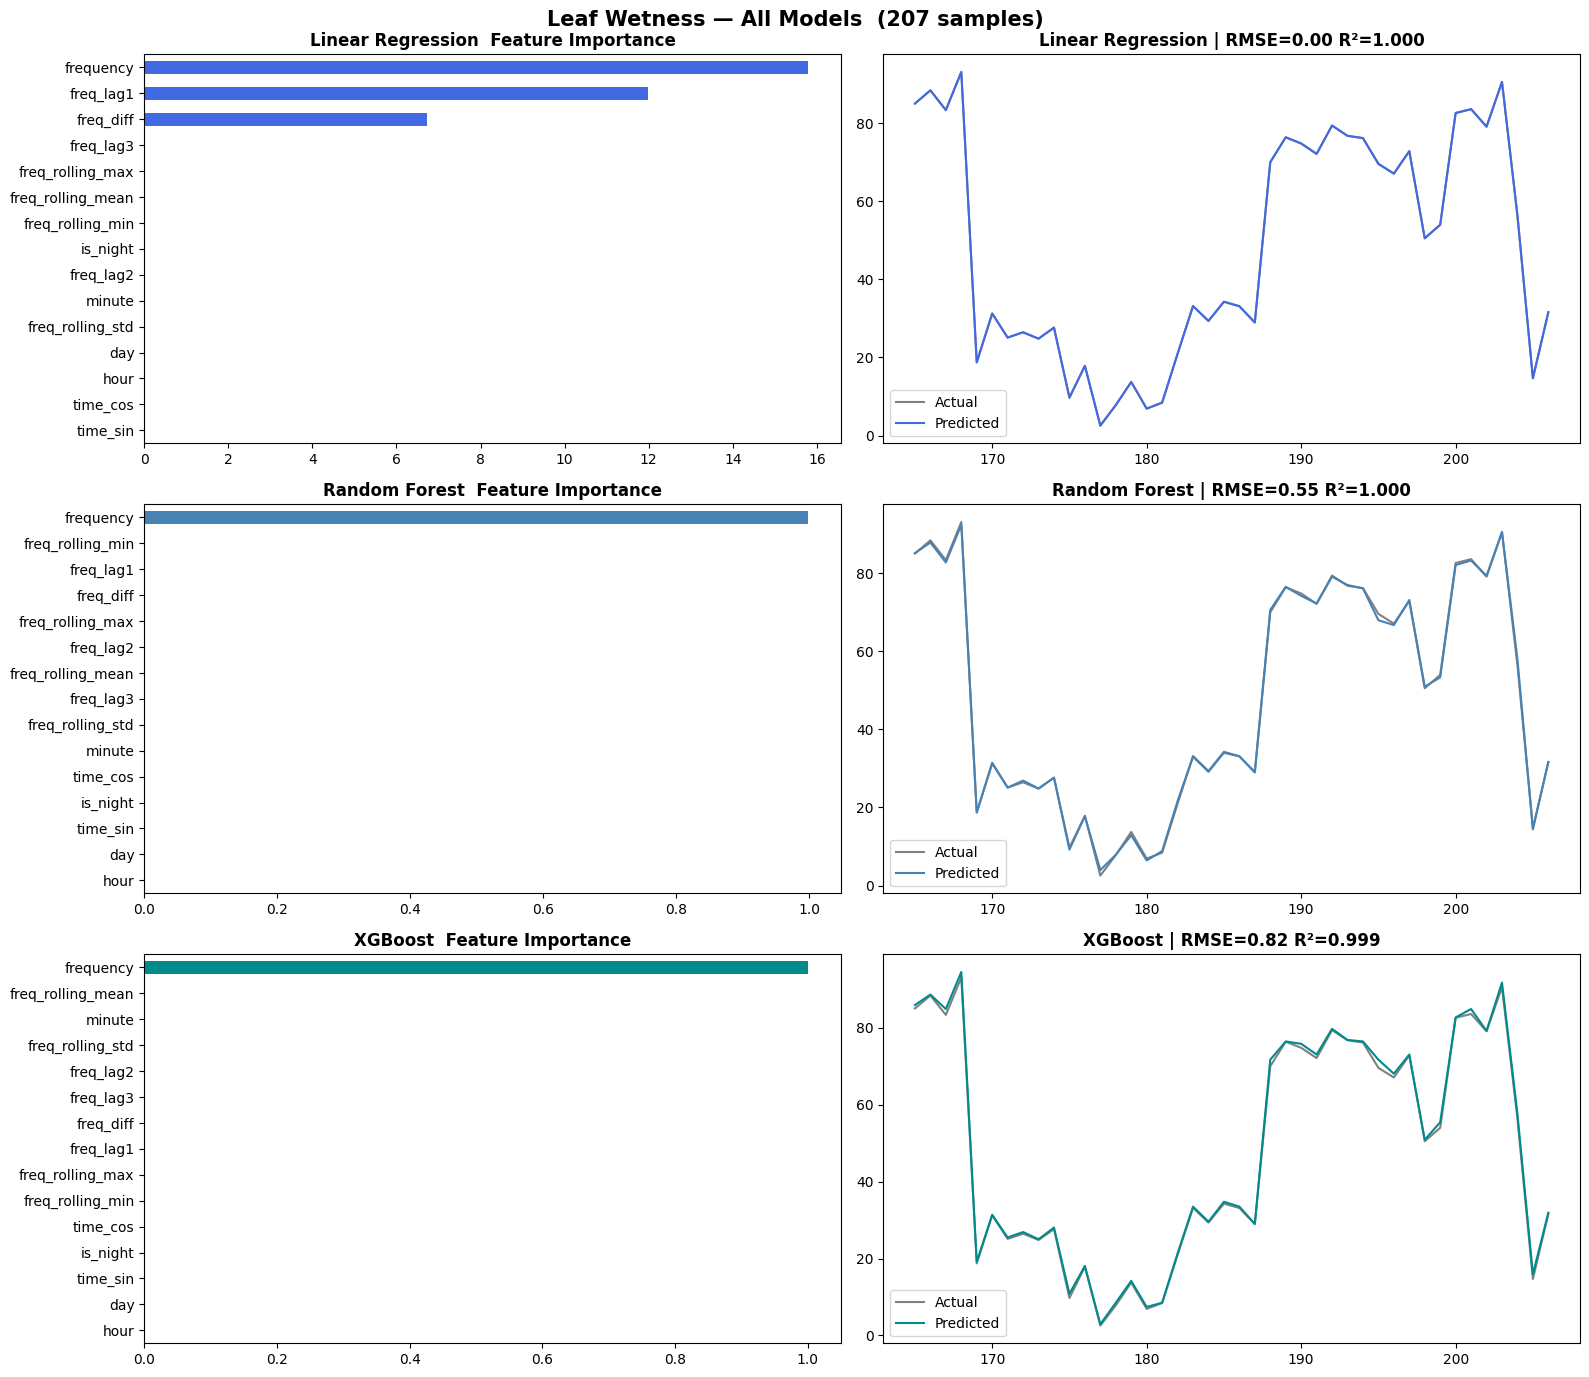

In [ ]:
ml(data12)

## Testing on Merged data

Loaded 727 rows
   time_sec     frequency      label
0       0.0  18246.230972  68.771587
1       1.0  18889.791627  64.800329
2       2.0  18297.158158  68.457327
3       3.0  18650.138808  66.279169
4       4.0  18187.707326  69.132722

Label range: 0.00 → 100.00
count    727.000000
mean      70.673088
std       22.398651
min        0.000000
25%       67.334586
50%       79.486179
75%       85.218974
max      100.000000
Name: label, dtype: float64

Total rows: 727 | Train: 581 | Test: 146

Model                      RMSE      MAE       R²    MAPE(%)
------------------------------------------------------------
Linear Regression         33.19    28.75   -0.300        inf
Random Forest              3.09     1.98    0.989        inf
XGBoost                    3.73     2.50    0.984        inf


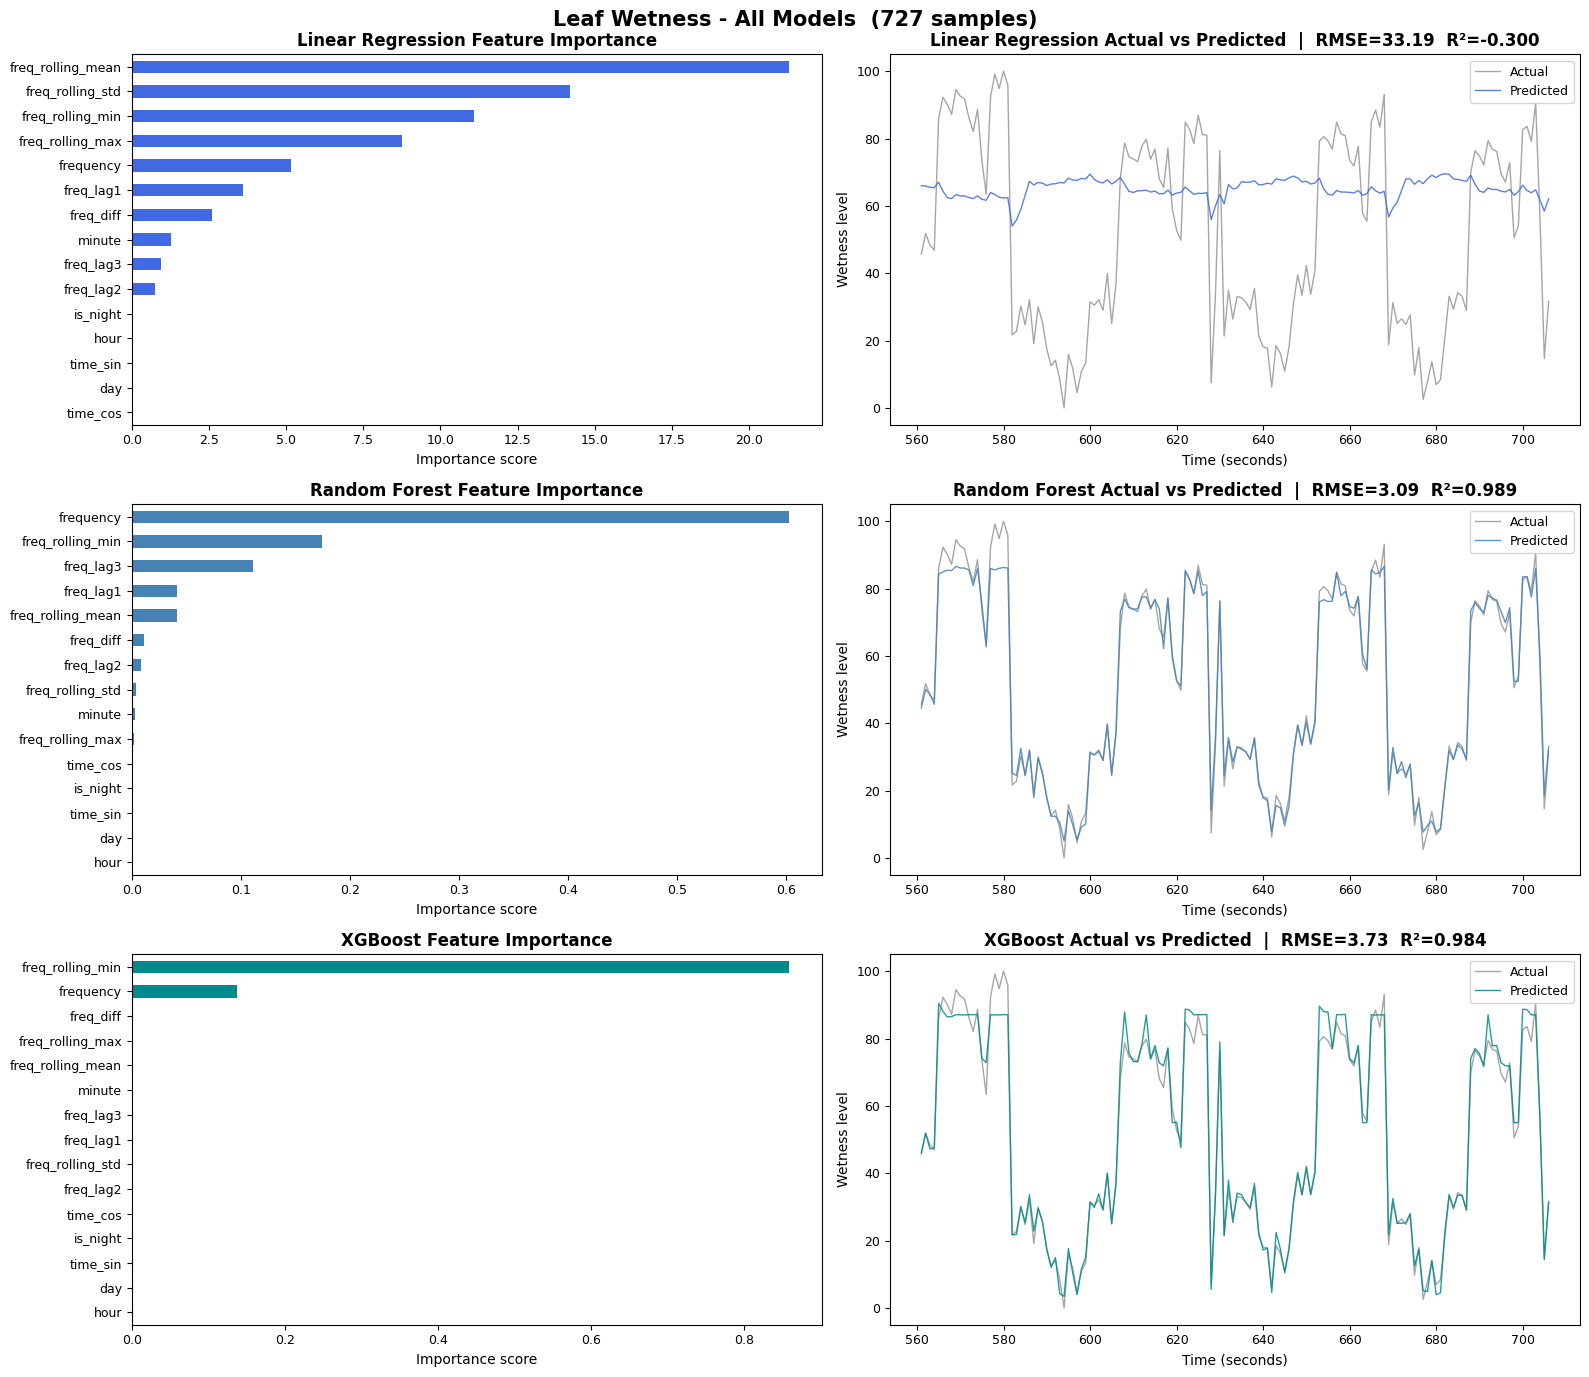

In [ ]:
ml2(df_final.to_numpy())